# Controlling an interferometer using EPICS and a stage using ophyd
awojdyla@lbl.gov, Feb 2026

In [ ]:
#!pip install pyepics
#!pip install ophyd
#!pip install newportxps

In [4]:
#using base 3.13.5 on GW
import epics
import ophyd

### create an ophyd wrapper for Newport XPS controller

In [9]:
from ophyd import Device, Component as Cpt, Signal
from ophyd import EpicsSignal
from ophyd.status import SubscriptionStatus
import threading
import time

class NewportXPSMotor(Device):
    # Ophyd signals
    user_readback = Cpt(Signal, value=0, kind='hinted')
    user_setpoint = Cpt(Signal, value=0, kind='normal')
    
    def __init__(self, ip_address, stage_name, username='Administrator', 
                 password='Administrator', *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        from newportxps import NewportXPS
        
        self.stage_name = stage_name
        self.group_name = stage_name.split('.')[0]  # Extract 'Group1' from 'Group1.Pos'
        self.xps = NewportXPS(ip_address, username=username, password=password)
        
        # Update initial position
        self._update_position()
        
    def _update_position(self):
        """Read current position from hardware"""
        pos = self.xps.read_stage_position(self.stage_name)
        self.user_readback.put(pos)
        return pos
    
    def _is_moving(self):
        """Check if the motor is currently moving"""
        status = self.xps.get_group_status()
        group_status = status.get(self.group_name, '')
        return 'Moving' in group_status
    
    def set(self, position, timeout=30):
        """Move to a position and return a status object"""
        
        def check_done(*, old_value, value, **kwargs):
            """Callback to check if motion is complete"""
            return not self._is_moving()
        
        # Start the move
        self.user_setpoint.put(position)
        self.xps.move_stage(self.stage_name, position)
        
        # Create a status object that monitors completion
        status = SubscriptionStatus(self.user_readback, check_done, timeout=timeout)
        
        # Start a background thread to update position during motion
        def monitor_motion():
            while not status.done:
                self._update_position()
                time.sleep(0.05)  # 50ms polling
            # Final position update
            self._update_position()
        
        thread = threading.Thread(target=monitor_motion, daemon=True)
        thread.start()
        
        return status
    
    def read(self):
        """Read current position"""
        pos = self._update_position()
        return {f'{self.name}_user_readback': {'value': pos, 'timestamp': time.time()}}
    
    def describe(self):
        """Describe the readback signal"""
        return {f'{self.name}_user_readback': {
            'source': f'XPS:{self.stage_name}',
            'dtype': 'number',
            'shape': []
        }}

### Instantiate the ophyd objects

In [10]:
#stock ophyd opbject for EPICS signal
interf = EpicsSignal('CATERETE:PICOSCALE:POS_0', name='interferometer_position')

#custom ophyd object
motor = NewportXPSMotor(
    ip_address='192.168.10.20',
    stage_name='Group1.Pos',
    username='Administrator',
    password='Administrator',
    name='xps_motor'
)

pos_inter_m = interf.get()*1e-12
pos_readback_m = motor.get()[0]*1e-3
print(f"Interferometer position: {pos_inter_m*1e3} mm")
print(f"Motor readback position: {pos_readback_m*1e3} mm")


Interferometer position: -1.2039923 mm
Motor readback position: 1.000001 mm


## Start the bluesky runengine
and subscribe it to the local tiled server

In [11]:
from tiled.client import from_uri
import os
from bluesky import plans as bp
from bluesky.callbacks.tiled_writer import TiledWriter

#import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
#api_key_filepath = "C:\\Users\\admin\\Documents\\TILED_SINGLE_USER_API_KEY.txt"
#with open(api_key_filepath, 'r') as f:
#    api_key = f.read().strip()
#os.environ["TILED_SINGLE_USER_API_KEY"] = api_key

if not api_key:
   raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
#from bluesky.callbacks.tiled_writer import TiledWriter

tiled_client = from_uri("http://localhost:8000/", api_key=api_key)
tw = TiledWriter(tiled_client)

from bluesky import RunEngine
RE = RunEngine()
RE.subscribe(tw)
from bluesky.callbacks.best_effort import BestEffortCallback
bec = BestEffortCallback()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

#RE(bp.scan([interf, motor], motor, -10, 10, 11))
#RE(bp.count([interf], 11))

1

## Reaing positions jitter



Transient Scan ID: 2     Time: 2026-03-17 22:47:08
Persistent Unique Scan ID: '050489ce-84ba-43a5-9e57-cd7a289affea'
New stream: 'primary'
+-----------+------------+-------------------------+
|   seq_num |       time | interferometer_position |
+-----------+------------+-------------------------+
|         1 | 22:47:08.8 |             -1204014610 |
|         2 | 22:47:08.8 |             -1204008884 |
|         3 | 22:47:08.9 |             -1204004635 |
|         4 | 22:47:08.9 |             -1204015319 |
|         5 | 22:47:09.0 |             -1204010978 |
|         6 | 22:47:09.0 |             -1204025943 |
|         7 | 22:47:09.1 |             -1204020958 |
|         8 | 22:47:09.1 |             -1204019639 |
|         9 | 22:47:09.2 |             -1204022388 |
|        10 | 22:47:09.2 |             -1204006563 |
|        11 | 22:47:09.2 |             -1204006266 |
|        12 | 22:47:09.3 |             -1204018945 |
|        13 | 22:47:09.3 |             -1204019479 |
|        14

('050489ce-84ba-43a5-9e57-cd7a289affea',)

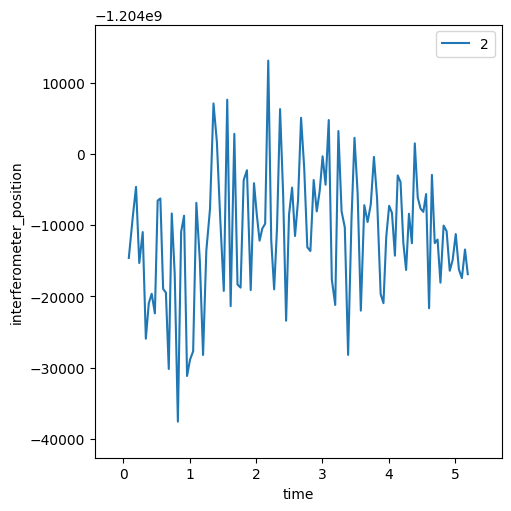

CA.Client.Exception...............................................
    Context: "192.168.10.56:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Mon Mar 23 2026 14:34:07.671913810
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.56:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Mon Mar 23 2026 15:03:03.041357191
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.56:5064"
    Source File: ../cac.cpp line 1237
    Current Time: Mon Mar 23 2026 15:17:10.943355612
..................................................................


In [ ]:
RE(bp.count([interf], 111))

## Linear motor scan



Transient Scan ID: 2     Time: 2026-03-16 13:08:26
Persistent Unique Scan ID: 'caaa9906-0036-4983-a294-7496bf92f6ca'
New stream: 'primary'
+-----------+------------+-------------------------+-------------------------+
|   seq_num |       time | xps_motor_user_readback | interferometer_position |
+-----------+------------+-------------------------+-------------------------+
|         1 | 13:08:27.1 |                 -10.000 |               688442393 |
|         2 | 13:08:27.3 |                  -8.000 |             -1781304191 |
|         3 | 13:08:27.4 |                  -6.000 |               393573137 |
|         4 | 13:08:27.6 |                  -4.000 |             -1911613701 |
|         5 | 13:08:27.8 |                  -2.000 |                 8938337 |
|         6 | 13:08:27.9 |                   0.000 |              1938962432 |
|         7 | 13:08:28.1 |                   2.000 |              -196656647 |
|         8 | 13:08:28.3 |                   4.000 |              177

('caaa9906-0036-4983-a294-7496bf92f6ca',)

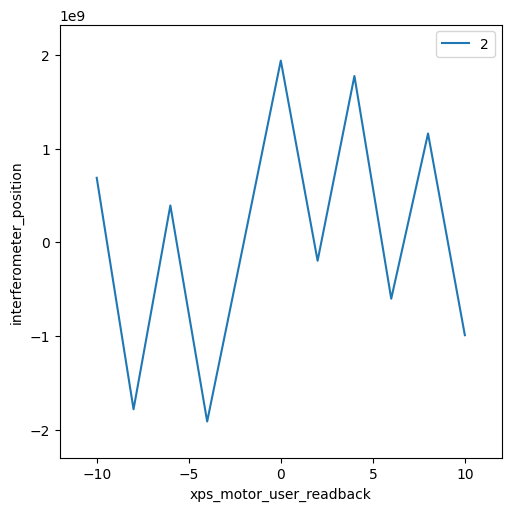

In [ ]:
RE(bp.scan([interf, motor], motor, -10, 10, 11))

In [ ]:
db = tiled_client['caaa9906-0036-4983-a294-7496bf92f6ca']
db['primary'].read()


<xarray.Dataset> Size: 528B
Dimensions:                     (dim0: 11)
Dimensions without coordinates: dim0
Data variables:
    ts_xps_motor_user_readback  (dim0) float64 88B 1.774e+09 ... 1.774e+09
    interferometer_position     (dim0) int64 88B 688442393 ... -990726556
    seq_num                     (dim0) int64 88B 1 2 3 4 5 6 7 8 9 10 11
    xps_motor_user_readback     (dim0) float64 88B -10.0 -8.0 -6.0 ... 8.0 10.0
    ts_interferometer_position  (dim0) float64 88B 1.774e+09 ... 1.774e+09
    time                        (dim0) float64 88B 1.774e+09 ... 1.774e+09

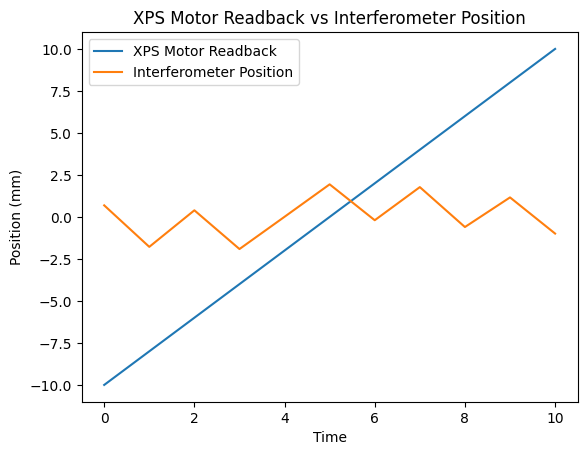

In [27]:
import matplotlib.pyplot as plt

xps_motor_user_readback = db['primary']['xps_motor_user_readback'].read()
interferometer_position = db['primary']['interferometer_position'].read()
plt.plot(xps_motor_user_readback, label='XPS Motor Readback')
plt.plot(interferometer_position*1e-9, label='Interferometer Position')
plt.xlabel('Time')
plt.ylabel('Position (mm)')
plt.title('XPS Motor Readback vs Interferometer Position')
plt.legend()
plt.show()